In [60]:
import joblib
from pathlib import Path

model_path = Path("../src/cofrisk/models/cofrisk_xgb_pipeline.joblib")

joblib.dump(final_model, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ../src/cofrisk/models/cofrisk_xgb_pipeline.joblib


In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [3]:
from cofrisk.data.validation import (
    EXPECTED_FEATURES,
    TARGET_COLUMN,
)

In [4]:
from scipy.io import arff

data, metadata = arff.loadarff(
    "../data/raw/1year.arff"
)

df = pd.DataFrame(data)

In [5]:
from cofrisk.data.cleaning import (
    remove_exact_duplicates,
    encode_target,
)

df = remove_exact_duplicates(df)
df = encode_target(df)


===== DUPLICATE REMOVAL =====
Rows before: 7027
Rows after:  6945
Rows removed: 82


In [6]:
df.head()
df["class"].value_counts()

class
0    6674
1     271
Name: count, dtype: int64

In [7]:
X = df[EXPECTED_FEATURES]
y = df[TARGET_COLUMN]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,
)

In [9]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5556, 64)
X_test : (1389, 64)
y_train: (5556,)
y_test : (1389,)


In [10]:
print("===== TRAIN =====")
print(y_train.value_counts())
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\n===== TEST =====")
print(y_test.value_counts())
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

===== TRAIN =====
class
0    5339
1     217
Name: count, dtype: int64
class
0    96.09
1     3.91
Name: proportion, dtype: float64

===== TEST =====
class
0    1335
1      54
Name: count, dtype: int64
class
0    96.11
1     3.89
Name: proportion, dtype: float64


In [11]:
imputer = SimpleImputer(
    strategy="median",
    add_indicator=True
)

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Avant preprocessing :", X_train.shape)
print("Après imputation    :", X_train_imputed.shape)

Avant preprocessing : (5556, 64)
Après imputation    : (5556, 113)


In [12]:
scaler = StandardScaler()

X_train_processed = scaler.fit_transform(X_train_imputed)
X_test_processed = scaler.transform(X_test_imputed)

print("Train :", X_train_processed.shape)
print("Test  :", X_test_processed.shape)

Train : (5556, 113)
Test  : (1389, 113)


In [13]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_processed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",2000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [14]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

y_pred = model.predict(X_test_processed)
y_proba = model.predict_proba(X_test_processed)[:, 1]

print("===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred))

print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print("PR-AUC  :", average_precision_score(y_test, y_proba))

===== CONFUSION MATRIX =====
[[1195  140]
 [   8   46]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1335
           1       0.25      0.85      0.38        54

    accuracy                           0.89      1389
   macro avg       0.62      0.87      0.66      1389
weighted avg       0.96      0.89      0.92      1389

ROC-AUC : 0.9361492578721042
PR-AUC  : 0.5103869673888667


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1
0,0.1,0.054545,1.000000,0.103448
1,0.2,0.085246,0.962963,0.156627
2,0.3,0.131367,0.907407,0.229508
3,0.4,0.180769,0.870370,0.299363
4,0.5,0.247312,0.851852,0.383333
5,0.6,0.333333,0.740741,0.459770
6,0.7,0.423529,0.666667,0.517986
7,0.8,0.445946,0.611111,0.515625
8,0.9,0.483871,0.555556,0.517241


In [16]:
# Random Forest 🌲

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_imputed, y_train)

y_pred_rf = rf.predict(X_test_imputed)
y_proba_rf = rf.predict_proba(X_test_imputed)[:, 1]

In [18]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
)

print("===== RANDOM FOREST =====")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC :", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC  :", average_precision_score(y_test, y_proba_rf))

===== RANDOM FOREST =====
[[1330    5]
 [  35   19]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1335
           1       0.79      0.35      0.49        54

    accuracy                           0.97      1389
   macro avg       0.88      0.67      0.74      1389
weighted avg       0.97      0.97      0.97      1389

ROC-AUC : 0.9275003467887363
PR-AUC  : 0.6265698687835282


In [19]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

results_rf = []

for threshold in thresholds:
    y_pred_threshold = (y_proba_rf >= threshold).astype(int)

    results_rf.append({
        "threshold": threshold,
        "precision": precision_score(
            y_test, y_pred_threshold, zero_division=0
        ),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
    })

threshold_results_rf = pd.DataFrame(results_rf)

threshold_results_rf

,threshold,precision,recall,f1
0,0.1,0.162069,0.870370,0.273256
1,0.2,0.393617,0.685185,0.500000
2,0.3,0.600000,0.611111,0.605505
3,0.4,0.771429,0.500000,0.606742
4,0.5,0.791667,0.351852,0.487179
5,0.6,0.888889,0.296296,0.444444
6,0.7,0.928571,0.240741,0.382353
7,0.8,1.000000,0.148148,0.258065
8,0.9,0.000000,0.000000,0.000000


In [20]:
from sklearn.metrics import matthews_corrcoef

mcc_lr = matthews_corrcoef(y_test, y_pred)
mcc_rf = matthews_corrcoef(y_test, y_pred_rf)

print("MCC Logistic Regression :", round(mcc_lr, 4))
print("MCC Random Forest       :", round(mcc_rf, 4))

MCC Logistic Regression : 0.424
MCC Random Forest       : 0.5164


In [21]:
mcc_results = []

for threshold in thresholds:
    pred_lr = (y_proba >= threshold).astype(int)
    pred_rf = (y_proba_rf >= threshold).astype(int)

    mcc_results.append({
        "threshold": threshold,
        "mcc_lr": matthews_corrcoef(y_test, pred_lr),
        "mcc_rf": matthews_corrcoef(y_test, pred_rf),
    })

mcc_results = pd.DataFrame(mcc_results)

mcc_results

,threshold,mcc_lr,mcc_rf
0,0.1,0.127681,0.327377
1,0.2,0.212270,0.494429
2,0.3,0.289914,0.589422
3,0.4,0.352260,0.609295
4,0.5,0.423993,0.516390
5,0.6,0.468431,0.503857
6,0.7,0.508047,0.464428
7,0.8,0.499558,0.378436
8,0.9,0.497599,0.000000


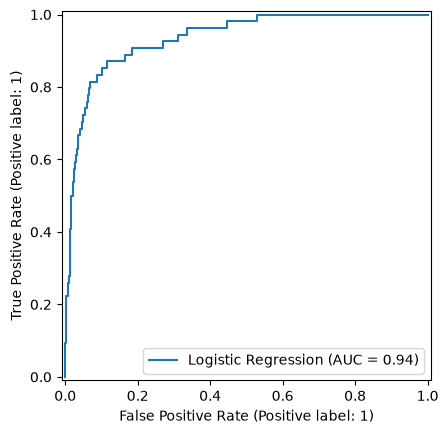

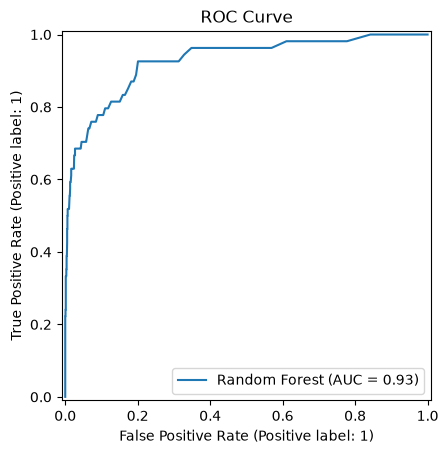

In [22]:
from sklearn.metrics import (
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
import matplotlib.pyplot as plt

# ROC curves
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest"
)

plt.title("ROC Curve")
plt.show()

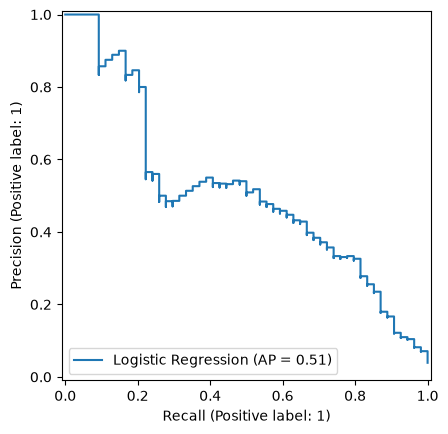

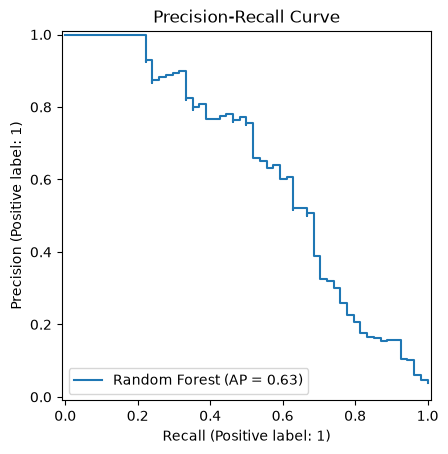

In [23]:
# Precision-Recall curves
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba,
    name="Logistic Regression"
)

PrecisionRecallDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest"
)

plt.title("Precision-Recall Curve")
plt.show()

In [24]:
feature_names = imputer.get_feature_names_out(X_train.columns)

importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print("===== TOP 20 FEATURES =====")
print(importance.head(20))

===== TOP 20 FEATURES =====
missingindicator_Attr27    0.087435
Attr27                     0.059274
Attr24                     0.037368
Attr13                     0.034174
Attr34                     0.033009
Attr23                     0.022507
Attr6                      0.022481
Attr46                     0.021576
Attr26                     0.021173
Attr29                     0.019501
Attr31                     0.019268
Attr5                      0.018657
Attr9                      0.017996
Attr58                     0.017755
Attr11                     0.017107
Attr19                     0.016670
Attr12                     0.016040
missingindicator_Attr11    0.015861
Attr1                      0.015714
Attr16                     0.015262
dtype: float64


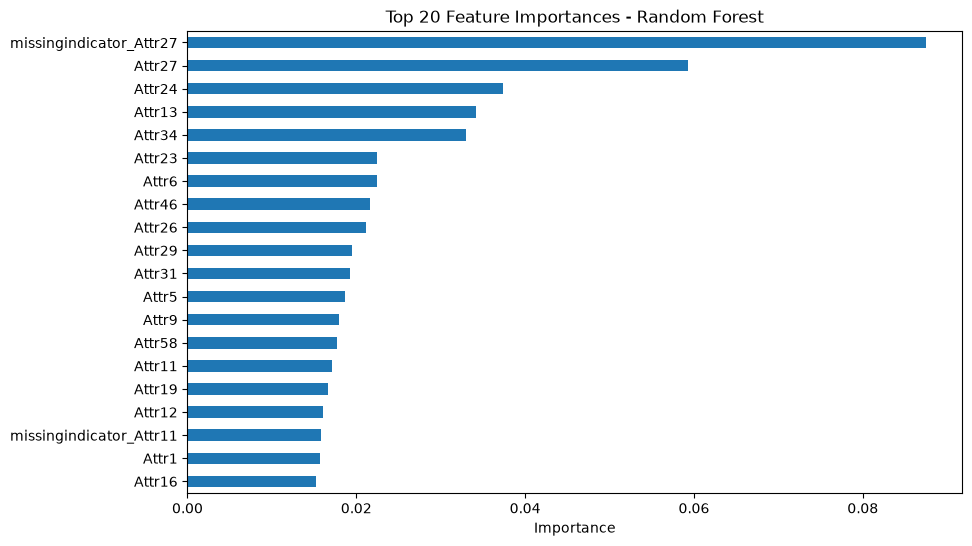

In [25]:
plt.figure(figsize=(10, 6))

importance.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

In [59]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test_imputed,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=feature_names
).sort_values(ascending=False)

print("===== PERMUTATION IMPORTANCE =====")
print(perm_importance.head(20))

===== PERMUTATION IMPORTANCE =====
missingindicator_Attr27    0.298620
missingindicator_Attr11    0.054812
Attr58                     0.050479
Attr27                     0.045448
Attr34                     0.039706
Attr46                     0.033586
Attr9                      0.017612
Attr11                     0.007854
missingindicator_Attr21    0.003373
Attr6                      0.002988
Attr5                      0.002172
Attr41                     0.001899
missingindicator_Attr41    0.000776
Attr56                     0.000712
missingindicator_Attr24    0.000197
missingindicator_Attr63    0.000020
missingindicator_Attr47    0.000015
missingindicator_Attr9     0.000000
missingindicator_Attr2     0.000000
missingindicator_Attr4     0.000000
dtype: float64


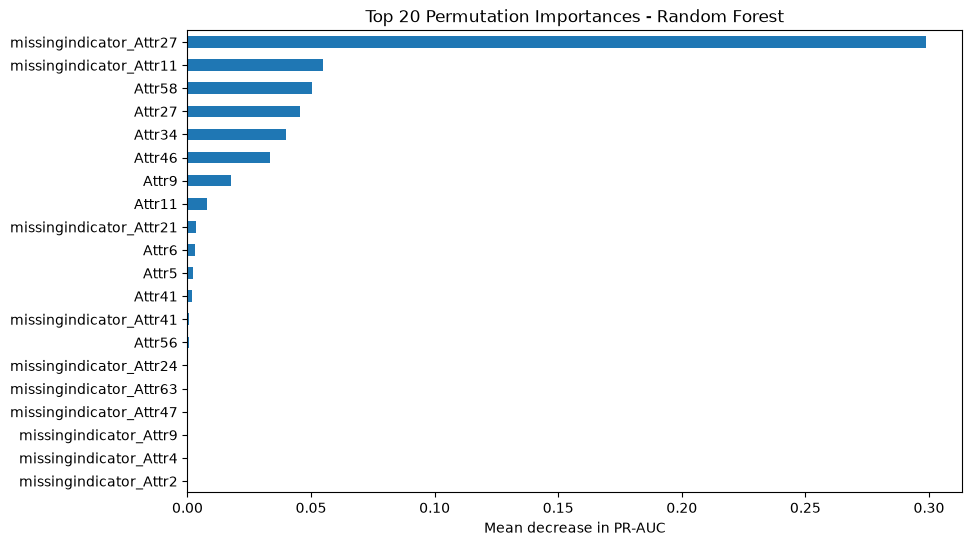

In [27]:
plt.figure(figsize=(10, 6))

perm_importance.head(20).sort_values().plot(kind="barh")

plt.title("Top 20 Permutation Importances - Random Forest")
plt.xlabel("Mean decrease in PR-AUC")
plt.show()

In [28]:
# pip install shap

In [29]:
explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(X_test_imputed)

In [30]:
print(type(shap_values))

if isinstance(shap_values, list):
    print("Nombre de classes :", len(shap_values))
    print("Shape classe 0 :", shap_values[0].shape)
    print("Shape classe 1 :", shap_values[1].shape)
else:
    print("Shape :", shap_values.shape)

<class 'numpy.ndarray'>
Shape : (1389, 113, 2)


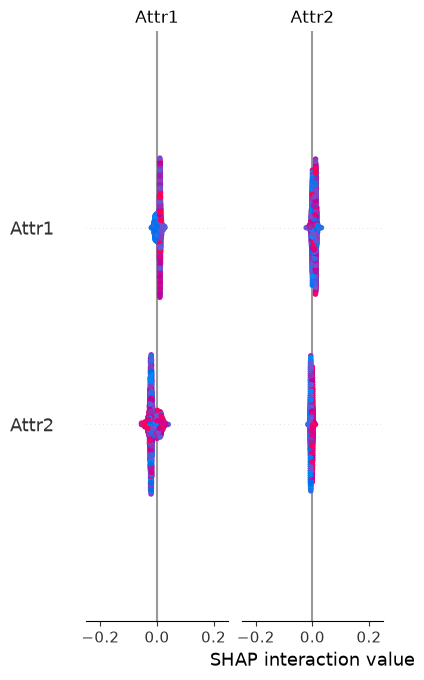

In [31]:
shap.summary_plot(
    shap_values,
    X_test_imputed,
    feature_names=feature_names
)

In [32]:
# pip install xgboost

In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    random_state=42,
    n_jobs=-1
)

In [34]:
xgb.fit(
    X_train_imputed,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_xgb = xgb.predict(X_test_imputed)

y_proba_xgb = xgb.predict_proba(
    X_test_imputed
)[:, 1]

In [36]:
comparison = pd.DataFrame({
    "model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba),
        average_precision_score(y_test, y_proba_rf),
        average_precision_score(y_test, y_proba_xgb)
    ],
    "MCC": [
        matthews_corrcoef(y_test, y_pred),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb)
    ]
})

comparison

,model,ROC-AUC,PR-AUC,MCC
0,Logistic Regression,0.936149,0.510387,0.423993
1,Random Forest,0.927500,0.626570,0.516390
2,XGBoost,0.966570,0.801426,0.726020


In [37]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )
    )
])

In [38]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [39]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    xgb_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "roc_auc": "roc_auc",
        "pr_auc": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

In [40]:
print("===== CROSS-VALIDATION =====")

print(
    "ROC-AUC par fold :",
    cv_results["test_roc_auc"]
)

print(
    "ROC-AUC moyen :",
    cv_results["test_roc_auc"].mean()
)

print(
    "ROC-AUC std :",
    cv_results["test_roc_auc"].std()
)

print(
    "PR-AUC par fold :",
    cv_results["test_pr_auc"]
)

print(
    "PR-AUC moyen :",
    cv_results["test_pr_auc"].mean()
)

print(
    "PR-AUC std :",
    cv_results["test_pr_auc"].std()
)

===== CROSS-VALIDATION =====
ROC-AUC par fold : [0.97108018 0.94009668 0.93787562 0.95222542 0.95590866]
ROC-AUC moyen : 0.9514373133471509
ROC-AUC std : 0.011991546140031263
PR-AUC par fold : [0.8192785  0.68173764 0.70253823 0.71403393 0.79863208]
PR-AUC moyen : 0.7432440762439754
PR-AUC std : 0.055031453447138


In [41]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5]
}

In [42]:
search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [43]:
search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum sco

In [44]:
print("===== BEST PARAMETERS =====")
print(search.best_params_)

print("\n===== BEST CV PR-AUC =====")
print(search.best_score_)

===== BEST PARAMETERS =====
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

===== BEST CV PR-AUC =====
0.7500563952938292


In [45]:
best_model = search.best_estimator_

In [46]:
y_proba_best = best_model.predict_proba(X_test)[:, 1]

y_pred_best = best_model.predict(X_test)

In [47]:
print("ROC-AUC :", roc_auc_score(y_test, y_proba_best))
print("PR-AUC  :", average_precision_score(y_test, y_proba_best))
print("MCC     :", matthews_corrcoef(y_test, y_pred_best))

print("\nClassification report:")
print(classification_report(y_test, y_pred_best))

ROC-AUC : 0.9632265224025524
PR-AUC  : 0.7806081441897286
MCC     : 0.6601697353391219

Classification report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1335
           1       0.93      0.48      0.63        54

    accuracy                           0.98      1389
   macro avg       0.95      0.74      0.81      1389
weighted avg       0.98      0.98      0.98      1389



In [48]:
print("===== BEST PARAMETERS =====")
print(search.best_params_)

print("\n===== BEST CV PR-AUC =====")
print(search.best_score_)

===== BEST PARAMETERS =====
{'model__subsample': 0.8, 'model__n_estimators': 200, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

===== BEST CV PR-AUC =====
0.7500563952938292


In [49]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=42
)

print("Train :", X_train_sub.shape)
print("Validation :", X_val.shape)
print("Test :", X_test.shape)

Train : (4444, 64)
Validation : (1112, 64)
Test : (1389, 64)


In [50]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

final_candidate = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )
    )
])

final_candidate.fit(X_train_sub, y_train_sub)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](64,)","['Attr1','Attr2','Attr3',...,'Attr62','Attr63','Attr64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing v

In [51]:
y_proba_val = final_candidate.predict_proba(X_val)[:, 1]

In [52]:
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef

thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
    0.70,
    0.80,
    0.90
]

results = []

for threshold in thresholds:
    y_pred = (y_proba_val >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_val, y_pred, zero_division=0),
        "recall": recall_score(y_val, y_pred, zero_division=0),
        "f1": f1_score(y_val, y_pred, zero_division=0),
        "mcc": matthews_corrcoef(y_val, y_pred)
    })

threshold_results = pd.DataFrame(results)

threshold_results

,threshold,precision,recall,f1,mcc
0,0.1,0.763158,0.674419,0.716049,0.706811
1,0.2,0.896552,0.604651,0.722222,0.728106
2,0.3,0.923077,0.558140,0.695652,0.709751
3,0.4,0.923077,0.558140,0.695652,0.709751
4,0.5,0.956522,0.511628,0.666667,0.691838
5,0.6,0.954545,0.488372,0.646154,0.674865
6,0.7,1.000000,0.488372,0.656250,0.691754
7,0.8,1.000000,0.488372,0.656250,0.691754
8,0.9,1.000000,0.441860,0.612903,0.657387


In [53]:
final_model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median",
            add_indicator=True
        )
    ),
    (
        "model",
        XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            min_child_weight=1,
            objective="binary:logistic",
            eval_metric="aucpr",
            random_state=42,
            n_jobs=-1
        )
    )
])

final_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](64,)","['Attr1','Attr2','Attr3',...,'Attr62','Attr63','Attr64']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,64
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",True
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing v

In [54]:
y_proba_test = final_model.predict_proba(X_test)[:, 1]

In [55]:
threshold = 0.20

y_pred_test = (
    y_proba_test >= threshold
).astype(int)

In [56]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    classification_report,
    confusion_matrix
)

print("===== FINAL TEST EVALUATION =====")

print("ROC-AUC :", roc_auc_score(y_test, y_proba_test))
print("PR-AUC  :", average_precision_score(y_test, y_proba_test))
print("MCC     :", matthews_corrcoef(y_test, y_pred_test))

print("\n===== CONFUSION MATRIX =====")
print(confusion_matrix(y_test, y_pred_test))

print("\n===== CLASSIFICATION REPORT =====")
print(classification_report(y_test, y_pred_test))

===== FINAL TEST EVALUATION =====
ROC-AUC : 0.9632265224025524
PR-AUC  : 0.7806081441897286
MCC     : 0.7164010290635229

===== CONFUSION MATRIX =====
[[1324   11]
 [  17   37]]

===== CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1335
           1       0.77      0.69      0.73        54

    accuracy                           0.98      1389
   macro avg       0.88      0.84      0.86      1389
weighted avg       0.98      0.98      0.98      1389



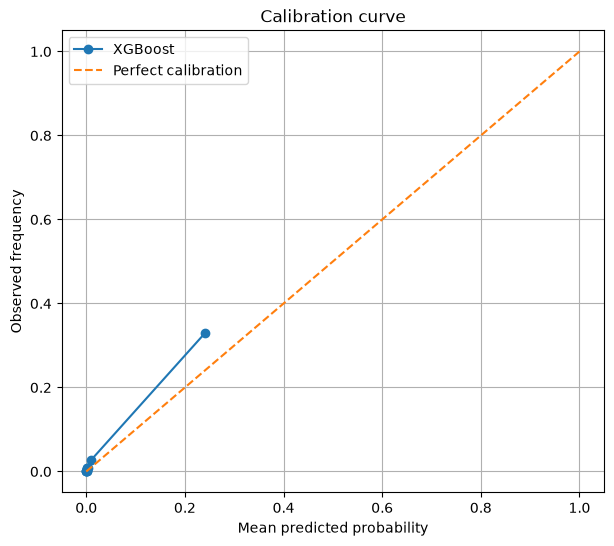

In [57]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_val,
    y_proba_val,
    n_bins=10,
    strategy="quantile"
)

plt.figure(figsize=(7, 6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration curve")
plt.legend()
plt.grid()
plt.show()

In [58]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_val,
    y_proba_val
)

print("Brier Score :", brier)

Brier Score : 0.016772063449025154
